# Proyecto Grupal - Inteligencia de Negocios
## Parte 3: Clasificación en BI

**Empresa:** Botica Los Andes  
**Objetivo:** Construir y evaluar un modelo de clasificación que permita identificar qué clientes del programa de fidelización tienen mayor probabilidad de abandonarlo (churn), usando como base el datamart construido en la Parte 1 (`data/processed/`).

##### 1. Definición del problema y variable objetivo

**Problema de negocio.** La gerencia de Botica Los Andes quiere anticipar qué clientes del programa de fidelización están en riesgo de dejar de comprar, para poder priorizar acciones de retención antes de perderlos.

**Variable objetivo.** La columna `churn` ya viene calculada en `Dim_Cliente.csv` (se generó en `00_generacion_datos.ipynb` a partir del historial real de compras simulado). Un cliente tiene `churn = 1` si, según la simulación, dejó de registrar compras después de cierto punto de su historial; `churn = 0` si se mantuvo activo. No se recalcula esta variable, se usa directamente como target.

1.1 Librerías y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

1.2 Carga de datos procesados

In [2]:
ruta_datos = "../data/processed/"

dim_cliente = pd.read_csv(ruta_datos + "Dim_Cliente.csv", sep=";")
dim_producto = pd.read_csv(ruta_datos + "Dim_Producto.csv", sep=";")
fact_ventas = pd.read_csv(ruta_datos + "Fact_Ventas.csv", sep=";")

dim_cliente["fecha_nacimiento"] = pd.to_datetime(dim_cliente["fecha_nacimiento"])
dim_cliente["fecha_alta"] = pd.to_datetime(dim_cliente["fecha_alta"])
fact_ventas["fecha"] = pd.to_datetime(fact_ventas["fecha"])

print(f"Dim_Cliente : {dim_cliente.shape}")
print(f"Dim_Producto: {dim_producto.shape}")
print(f"Fact_Ventas : {fact_ventas.shape}")

Dim_Cliente : (5000, 8)
Dim_Producto: (500, 7)
Fact_Ventas : (59700, 12)


##### 2. Construcción de la tabla analítica (feature engineering)

Para predecir el abandono no basta con las columnas de `Dim_Cliente`; hay que resumir el comportamiento de compra de cada cliente en `Fact_Ventas` (cuánto compra, con qué frecuencia, hace cuánto fue su última compra, etc.). Se construyen variables de tipo RFM (Recencia, Frecuencia, Monto) y algunas adicionales sugeridas en las instrucciones del proyecto: antigüedad, categorías compradas y uso de promociones.

2.1 Fecha de referencia

Como el dataset es histórico (no hay un "hoy" real), se usa la fecha máxima registrada en `Fact_Ventas` como fecha de corte para calcular antigüedad y recencia.

In [3]:
fecha_referencia = fact_ventas["fecha"].max()
print(f"Fecha de referencia: {fecha_referencia.date()}")

Fecha de referencia: 2025-12-30


2.2 Variables de comportamiento de compra por cliente

In [4]:
ventas_cliente = fact_ventas.merge(
    dim_producto[["id_producto", "categoria"]], on="id_producto", how="left"
)

agg_cliente = ventas_cliente.groupby("id_cliente").agg(
    frecuencia=("id_venta", "nunique"),
    n_lineas=("id_venta", "size"),
    monto_total=("importe", "sum"),
    fecha_ultima_compra=("fecha", "max"),
    n_categorias=("categoria", "nunique"),
    n_con_promocion=("id_promocion", lambda x: x.notna().sum()),
).reset_index()

agg_cliente["recencia_dias"] = (fecha_referencia - agg_cliente["fecha_ultima_compra"]).dt.days
agg_cliente["ticket_promedio"] = agg_cliente["monto_total"] / agg_cliente["frecuencia"]
agg_cliente["pct_compras_con_promocion"] = agg_cliente["n_con_promocion"] / agg_cliente["n_lineas"]

agg_cliente.head()

,id_cliente,frecuencia,n_lineas,monto_total,fecha_ultima_compra,n_categorias,n_con_promocion,recencia_dias,ticket_promedio,pct_compras_con_promocion
0,1,5,5,337.55,2025-07-13,4,1,170,67.510000,0.200000
1,2,5,5,211.37,2025-08-24,4,4,128,42.274000,0.800000
2,3,5,5,502.38,2025-07-04,4,3,179,100.476000,0.600000
3,4,6,6,493.15,2025-06-01,4,1,212,82.191667,0.166667
4,5,1,1,102.96,2024-12-14,1,1,381,102.960000,1.000000


2.3 Unión con Dim_Cliente y variables adicionales

In [5]:
df_features = dim_cliente.merge(agg_cliente, on="id_cliente", how="left")

df_features["antiguedad_dias"] = (fecha_referencia - df_features["fecha_alta"]).dt.days
df_features["edad"] = ((fecha_referencia - df_features["fecha_nacimiento"]).dt.days / 365.25).round(1)

print(f"Clientes sin ninguna compra registrada: {df_features['frecuencia'].isna().sum()}")

Clientes sin ninguna compra registrada: 324


2.4 Clientes sin compras registradas

Algunos clientes del programa no tienen ninguna línea en `Fact_Ventas` (se dieron de alta pero nunca llegaron a comprar). Para ellos, las variables de comportamiento se completan con 0, y la recencia se define igual a su antigüedad, ya que no tienen fecha de última compra.

In [6]:
cols_cero = [
    "frecuencia", "n_lineas", "monto_total", "n_categorias",
    "n_con_promocion", "ticket_promedio", "pct_compras_con_promocion",
]
df_features[cols_cero] = df_features[cols_cero].fillna(0)
df_features["recencia_dias"] = df_features["recencia_dias"].fillna(df_features["antiguedad_dias"])

df_features.isna().sum()

id_cliente                     0
nombre                         0
sexo                           0
fecha_nacimiento               0
distrito                       0
fecha_alta                     0
segmento_programa              0
churn                          0
frecuencia                     0
n_lineas                       0
monto_total                    0
fecha_ultima_compra          324
n_categorias                   0
n_con_promocion                0
recencia_dias                  0
ticket_promedio                0
pct_compras_con_promocion      0
antiguedad_dias                0
edad                           0
dtype: int64

2.5 Selección de variables para el modelo

In [7]:
features_numericas = [
    "antiguedad_dias", "recencia_dias", "frecuencia", "monto_total",
    "ticket_promedio", "n_categorias", "pct_compras_con_promocion", "edad",
]
features_categoricas = ["sexo", "segmento_programa"]

df_modelo = df_features[["id_cliente"] + features_numericas + features_categoricas + ["churn"]].copy()
df_modelo.describe()

,id_cliente,antiguedad_dias,recencia_dias,frecuencia,monto_total,ticket_promedio,n_categorias,pct_compras_con_promocion,edad,churn
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,2500.500000,893.374400,272.744600,11.94000,890.712318,70.920166,4.126600,0.374807,54.43846,0.214200
std,1443.520003,115.150811,261.637742,18.07995,1383.165850,54.572304,2.491147,0.331333,20.72288,0.410307
min,1.000000,699.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,18.00000,0.000000
25%,1250.750000,792.000000,40.000000,3.00000,135.020000,41.620625,2.000000,0.000000,36.40000,0.000000
50%,2500.500000,891.000000,181.000000,5.00000,354.505000,64.568000,4.000000,0.333333,54.80000,0.000000
75%,3750.250000,994.000000,450.000000,11.00000,954.450000,88.110000,6.000000,0.576049,72.10000,0.000000
max,5000.000000,1093.000000,1090.000000,123.00000,9727.280000,1053.630000,8.000000,1.000000,89.90000,1.000000


##### 3. Análisis exploratorio de datos (EDA)

3.1 Balance de clases

churn
0    3929
1    1071
Name: count, dtype: int64
churn
0    78.58
1    21.42
Name: proportion, dtype: float64


C:\Users\kenne\AppData\Local\Temp\ipykernel_11912\1317475455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_modelo, x="churn", palette=["#297FB8", "#C0392B"])


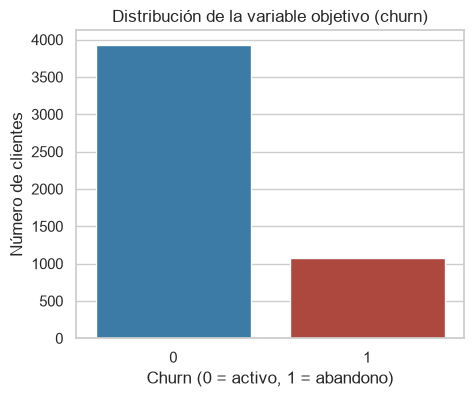

In [8]:
print(df_modelo["churn"].value_counts())
print((df_modelo["churn"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(5, 4))
sns.countplot(data=df_modelo, x="churn", palette=["#297FB8", "#C0392B"])
plt.title("Distribución de la variable objetivo (churn)")
plt.xlabel("Churn (0 = activo, 1 = abandono)")
plt.ylabel("Número de clientes")
plt.show()

La proporción real de clientes en abandono es de 21.4% (1071 de 5000 clientes), dentro del rango de 20-25% que se buscó al generar los datos. No es un desbalance extremo, pero sí lo suficiente como para tenerlo en cuenta al entrenar los modelos (se usa `class_weight="balanced"` más adelante).

3.2 Distribución de variables clave por clase

C:\Users\kenne\AppData\Local\Temp\ipykernel_11912\3007837080.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_modelo, x="churn", y=col, ax=ax, palette=["#297FB8", "#C0392B"])
C:\Users\kenne\AppData\Local\Temp\ipykernel_11912\3007837080.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_modelo, x="churn", y=col, ax=ax, palette=["#297FB8", "#C0392B"])
C:\Users\kenne\AppData\Local\Temp\ipykernel_11912\3007837080.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_modelo, x="churn", y=col, ax=ax, palette=["#297FB8", "

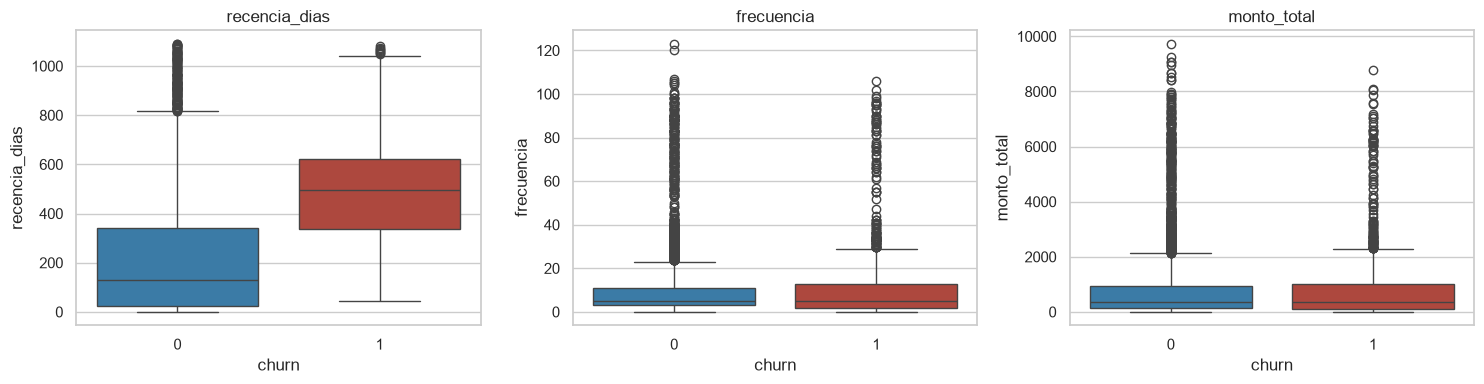

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["recencia_dias", "frecuencia", "monto_total"]):
    sns.boxplot(data=df_modelo, x="churn", y=col, ax=ax, palette=["#297FB8", "#C0392B"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

Se espera que los clientes con `churn = 1` tengan una recencia más alta (llevan más días sin comprar) y valores más bajos de frecuencia y monto acumulado, ya que la propia lógica de simulación del abandono se basa en que el cliente dejó de generar compras en algún punto de su historial.

3.3 Tasa de abandono por segmento del programa

segmento_programa
Oro             0.239044
Sin Programa    0.219688
Plata           0.212000
Bronce          0.202000
Name: churn, dtype: float64


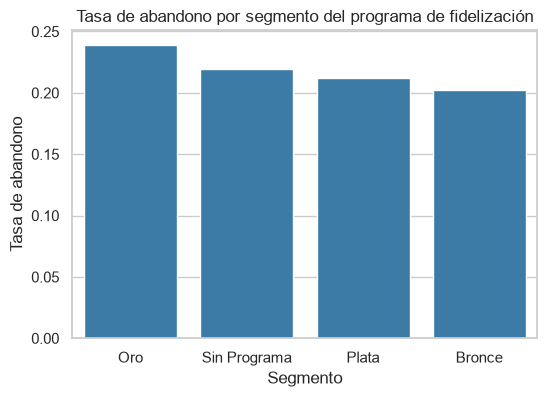

In [10]:
churn_segmento = df_modelo.groupby("segmento_programa")["churn"].mean().sort_values(ascending=False)
print(churn_segmento)

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_segmento.index, y=churn_segmento.values, color="#297FB8")
plt.ylabel("Tasa de abandono")
plt.xlabel("Segmento")
plt.title("Tasa de abandono por segmento del programa de fidelización")
plt.show()

Las diferencias en la tasa de abandono entre segmentos son pequeñas (entre 20.2% en Bronce y 23.9% en Oro), y el segmento Oro que tiene clientes históricamente más frecuentes es el que tiene la tasa más alta, no la más baja. Esto tiene sentido si se considera que el segmento se asigna según la frecuencia acumulada de compra en todo el historial, mientras que el abandono depende de qué tan reciente fue la última compra: un cliente puede haber comprado mucho en el pasado (y por eso llegar a Oro) y aun así haber dejado de comprar en los últimos meses. Esta baja capacidad de separación del segmento se confirma más adelante, cuando su importancia dentro del modelo resulta casi nula.

3.4 Correlación entre variables numéricas y churn

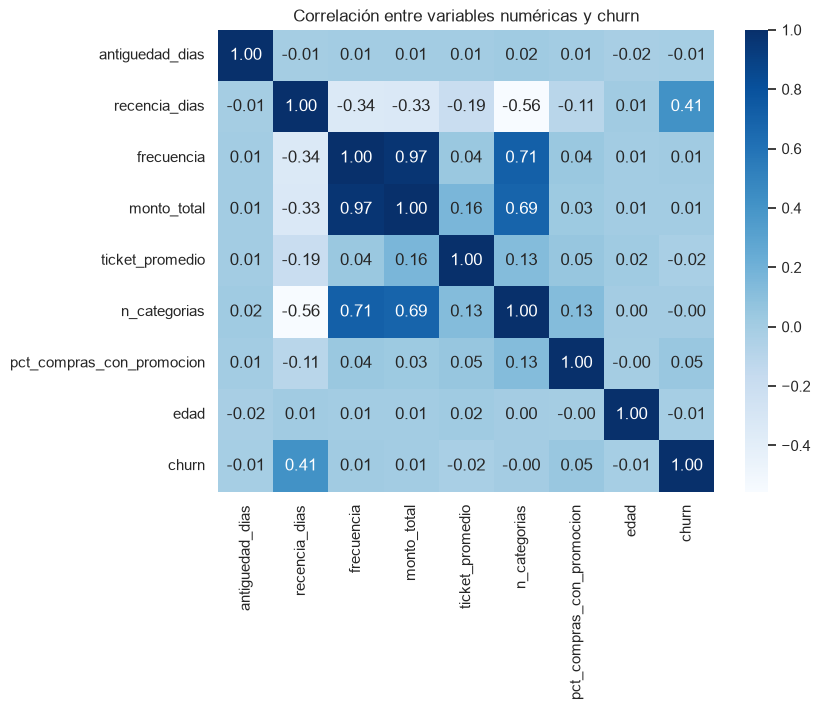

In [11]:
plt.figure(figsize=(8, 6))
corr = df_modelo[features_numericas + ["churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlación entre variables numéricas y churn")
plt.show()

No se observan variables numéricas con correlaciones extremas entre sí (no hay indicios claros de multicolinealidad grave), y `recencia_dias` es, como se anticipaba en el punto anterior, la variable con mayor correlación con `churn`. No se aplican transformaciones adicionales de outliers en esta etapa porque los datos ya pasaron por el proceso de limpieza de la Parte 1.

##### 4. División en entrenamiento y prueba

Se usa una división estratificada 75/25 para mantener la misma proporción de clientes en abandono en ambos conjuntos, con semilla fija para que el experimento sea reproducible.

In [12]:
X = df_modelo[features_numericas + features_categoricas]
y = df_modelo["churn"]

X = pd.get_dummies(X, columns=features_categoricas, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} clientes ({X_train.shape[1]} variables)")
print(f"Prueba      : {X_test.shape[0]} clientes")
print(f"Proporción de churn en train: {y_train.mean():.3f}")
print(f"Proporción de churn en test : {y_test.mean():.3f}")

Entrenamiento: 3750 clientes (12 variables)
Prueba      : 1250 clientes
Proporción de churn en train: 0.214
Proporción de churn en test : 0.214


4.1 Escalado de variables para la regresión logística

La regresión logística es sensible a la escala de las variables (antigüedad en días vs. porcentaje de compras con promoción, por ejemplo), así que se estandarizan solo para ese modelo. Los modelos basados en árboles no lo necesitan.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### 5. Entrenamiento y comparación de modelos

Se entrenan tres modelos con complejidad creciente, todos con semilla 42 y balanceando las clases, para comparar su desempeño y quedarnos con el que mejor equilibre precisión y capacidad de detectar a los clientes en riesgo.

5.1 Regresión logística

In [14]:
modelo_log = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
modelo_log.fit(X_train_scaled, y_train)

pred_log = modelo_log.predict(X_test_scaled)
proba_log = modelo_log.predict_proba(X_test_scaled)[:, 1]

5.2 Árbol de decisión

In [15]:
modelo_arbol = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)
proba_arbol = modelo_arbol.predict_proba(X_test)[:, 1]

5.3 Random forest

In [16]:
modelo_rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)
proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

##### 6. Evaluación de modelos

Se evalúan los tres modelos con matriz de confusión, precisión, recall, F1 y ROC-AUC. El recall de la clase `churn = 1` es especialmente importante en este caso: es más costoso no detectar a un cliente que se va a ir, que gastar un poco de esfuerzo de retención en alguien que en realidad se iba a quedar.

In [18]:
def evaluar_modelo(nombre, y_true, y_pred, y_proba):
    print(f"\n{'-' * 60}")
    print(f"Modelo: {nombre}")
    print(f"{'-' * 60}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_true, y_pred))
    print()
    print(classification_report(y_true, y_pred, digits=3))
    print(f"ROC-AUC: {roc_auc_score(y_true, y_proba):.3f}")


evaluar_modelo("Regresión logística", y_test, pred_log, proba_log)
evaluar_modelo("Árbol de decisión", y_test, pred_arbol, proba_arbol)
evaluar_modelo("Random forest", y_test, pred_rf, proba_rf)


------------------------------------------------------------
Modelo: Regresión logística
------------------------------------------------------------
Matriz de confusión:
[[752 230]
 [ 59 209]]

              precision    recall  f1-score   support

           0      0.927     0.766     0.839       982
           1      0.476     0.780     0.591       268

    accuracy                          0.769      1250
   macro avg      0.702     0.773     0.715      1250
weighted avg      0.831     0.769     0.786      1250

ROC-AUC: 0.831

------------------------------------------------------------
Modelo: Árbol de decisión
------------------------------------------------------------
Matriz de confusión:
[[709 273]
 [ 52 216]]

              precision    recall  f1-score   support

           0      0.932     0.722     0.814       982
           1      0.442     0.806     0.571       268

    accuracy                          0.740      1250
   macro avg      0.687     0.764     0.692      1

6.1 Tabla comparativa

In [19]:
resumen = pd.DataFrame({
    "Modelo": ["Regresión logística", "Árbol de decisión", "Random forest"],
    "ROC-AUC": [
        roc_auc_score(y_test, proba_log),
        roc_auc_score(y_test, proba_arbol),
        roc_auc_score(y_test, proba_rf),
    ],
    "F1 (churn=1)": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_arbol),
        f1_score(y_test, pred_rf),
    ],
}).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

resumen

,Modelo,ROC-AUC,F1 (churn=1)
0,Random forest,0.863170,0.601019
1,Árbol de decisión,0.841473,0.570674
2,Regresión logística,0.830889,0.591231


6.2 Curvas ROC

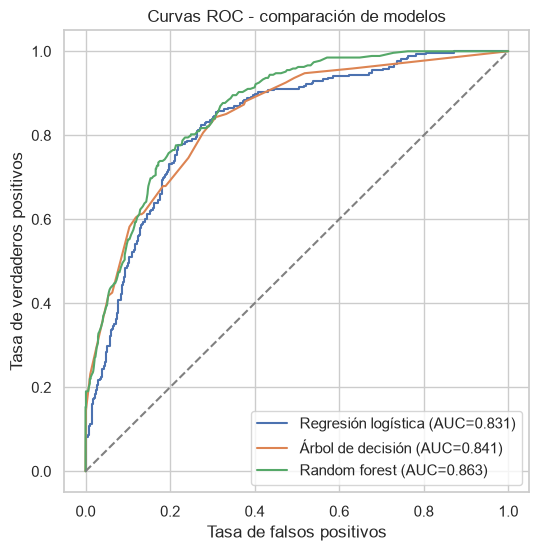

In [20]:
plt.figure(figsize=(6, 6))
for nombre, proba in [
    ("Regresión logística", proba_log),
    ("Árbol de decisión", proba_arbol),
    ("Random forest", proba_rf),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_test, proba):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC - comparación de modelos")
plt.legend()
plt.show()

**Elección del modelo final.** Los tres modelos tienen un desempeño razonable, pero con patrones distintos. Random Forest logra el mejor ROC-AUC (0.863) y también el mejor F1 para la clase de interés (0.601 frente a 0.591 de la regresión logística y 0.571 del árbol de decisión), es decir, es el que mejor ordena a los clientes de mayor a menor riesgo y el que logra el mejor equilibrio entre precisión y recall con el umbral por defecto. Sin embargo, con el umbral de decisión de 0.5 su recall sobre la clase `churn = 1` es el más bajo de los tres (0.660), lo que significa que clasificaría como "no abandono" a poco más de un tercio de los clientes que en realidad se van. La regresión logística y el árbol de decisión priorizan mucho más el recall (0.780 y 0.806 respectivamente), a costa de más falsos positivos: detectan a más clientes en riesgo real, pero también marcan como riesgo a muchos que en realidad se iban a quedar.

Aun así, se elige **Random Forest** como modelo final, porque el entregable de este análisis no es una etiqueta binaria automática sino una tabla de probabilidad de abandono con niveles de riesgo (sección 8) que se consume en Power BI. Para ese uso importa más qué tan bien ordena el modelo a los clientes según su riesgo real (ROC-AUC) que el resultado de un corte fijo en 0.5: el equipo de retención puede ampliar la cobertura de clientes atendidos simplemente bajando el umbral de riesgo "Medio" o "Alto" en el tablero, sin necesidad de reentrenar el modelo.

##### 7. Interpretación del modelo final

7.1 Importancia de variables

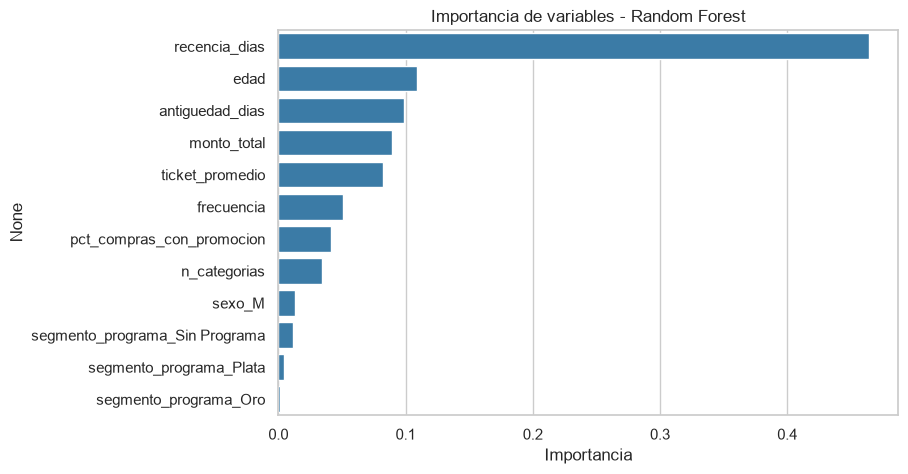

recencia_dias                     0.464156
edad                              0.109276
antiguedad_dias                   0.098530
monto_total                       0.089251
ticket_promedio                   0.081987
frecuencia                        0.050797
pct_compras_con_promocion         0.041433
n_categorias                      0.034334
sexo_M                            0.013371
segmento_programa_Sin Programa    0.011749
segmento_programa_Plata           0.004060
segmento_programa_Oro             0.001055
dtype: float64

In [21]:
importancias = pd.Series(
    modelo_rf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index, color="#297FB8")
plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.show()

importancias

`recencia_dias` domina claramente la importancia del modelo, con cerca del 46% del total, lo cual es coherente con la forma en que se etiquetó el abandono durante la generación de datos. Le siguen `edad`, `antiguedad_dias`, `monto_total` y `ticket_promedio`, cada una aportando entre 8% y 11%; `frecuencia`, `pct_compras_con_promocion` y `n_categorias` aportan menos. El sexo y el segmento del programa (variables dummy) tienen una importancia casi nula, lo que confirma lo observado en el EDA: el abandono en este negocio está más ligado al comportamiento reciente de compra que al perfil demográfico básico o al nivel alcanzado en el programa de fidelización. Que `edad` aparezca en segundo lugar, por delante de variables de comportamiento como `frecuencia`, es un resultado a tener en cuenta al momento de traducir el modelo en recomendaciones de negocio, ya que no tiene una interpretación tan directa como la recencia.

##### 8. Exportación de predicciones para Power BI

Se genera una tabla con la probabilidad de abandono de cada cliente del conjunto de prueba, junto con un nivel de riesgo (Bajo/Medio/Alto). Esta tabla alimentará la página de "Riesgo de abandono" en Power BI.

In [22]:
predicciones = X_test.copy()
predicciones["id_cliente"] = df_modelo.loc[X_test.index, "id_cliente"].values
predicciones["churn_real"] = y_test.values
predicciones["probabilidad_abandono"] = proba_rf
predicciones["prediccion"] = pred_rf

predicciones_export = predicciones[
    ["id_cliente", "churn_real", "probabilidad_abandono", "prediccion"]
].copy()

predicciones_export["nivel_riesgo"] = pd.cut(
    predicciones_export["probabilidad_abandono"],
    bins=[-0.01, 0.33, 0.66, 1],
    labels=["Bajo", "Medio", "Alto"],
)

predicciones_export.to_csv(
    "../data/processed/predicciones_churn.csv", sep=";", index=False
)

print(f"Clientes exportados: {len(predicciones_export)}")
predicciones_export["nivel_riesgo"].value_counts()

Clientes exportados: 1250


nivel_riesgo
Bajo     781
Medio    306
Alto     163
Name: count, dtype: int64

In [23]:
predicciones_export.head(10)

,id_cliente,churn_real,probabilidad_abandono,prediccion,nivel_riesgo
4273,4274,0,0.025,0,Bajo
820,821,0,0.515,1,Medio
764,765,0,0.205,0,Bajo
2802,2803,0,0.010,0,Bajo
1464,1465,0,0.190,0,Bajo
2825,2826,0,0.060,0,Bajo
700,701,0,0.465,0,Medio
1883,1884,0,0.045,0,Bajo
3351,3352,1,0.970,1,Alto
3829,3830,0,0.445,0,Medio


##### 9. Conclusiones

El modelo de Random Forest ordena razonablemente bien a los clientes según su probabilidad de abandono (ROC-AUC de 0.86), impulsado principalmente por la recencia de compra, seguida de la edad, la antigüedad en el programa y el monto acumulado. El sexo y el segmento del programa aportan muy poco, lo que indica que el abandono en Botica Los Andes está más relacionado con el comportamiento reciente de compra que con el perfil demográfico o el nivel de fidelización alcanzado. Como el modelo se usa como herramienta de priorización (probabilidad y nivel de riesgo) y no como una decisión automática, el equipo de retención puede ajustar cuántos clientes de riesgo "Medio" y "Alto" atender según su capacidad operativa. Las recomendaciones específicas de retención por nivel de riesgo se desarrollan en el informe consolidado del proyecto, junto con la integración de esta tabla en el tablero de Power BI.